# How to Train a Custom Keypoint Detection Model with PyTorch

## 1. Imports

In [2]:
import os, json, cv2, numpy as np, matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F

import albumentations as A

In [3]:
# https://github.com/pytorch/vision/tree/main/references/detection
from detection import transforms, utils, engine
from detection.utils import collate_fn
from detection.engine import train_one_epoch, evaluate

## 2. Augmentations

In [ ]:
def train_transform():
    return A.Compose([
        # Transformações geométricas
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.8, 1.2),         # Escala de 80% a 120%
            translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # Deslocamento até 10%
            rotate=(-15, 15),          # Rotação de -15° a +15°
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7
        ),

        # Transformações de cor/intensidade (importantes para raio-X)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
            A.RandomGamma(gamma_limit=(70, 130), p=1),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1),  # Bom para imagens médicas
        ], p=0.8),

        # Ruído e blur (simula variações de qualidade de imagem)
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.1), p=1),
            A.GaussianBlur(blur_limit=(3, 5), p=1),
            A.MedianBlur(blur_limit=3, p=1),
        ], p=0.3),

        # Transformações adicionais
        A.RandomRotate90(p=0.5),
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False),
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['bboxes_labels'])
    )

## 3. Dataset class

In [5]:
class ClassDataset(Dataset):
    def __init__(self, root, transform=None, demo=False):
        self.root = root
        self.transform = transform
        self.demo = demo # Use demo=True if you need transformed and original images (for example, for visualization purposes)
        self.imgs_files = sorted(os.listdir(os.path.join(root, "images")))
        self.annotations_files = sorted(os.listdir(os.path.join(root, "labels")))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "images", self.imgs_files[idx])
        annotations_path = os.path.join(self.root, "labels", self.annotations_files[idx])

        img_original = cv2.imread(img_path)
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

        with open(annotations_path) as f:
            data = json.load(f)
            bboxes_original = data['bboxes']
            keypoints_original = data['keypoints']

            # All objects are vertebrae
            bboxes_labels_original = ['Vertebra' for _ in bboxes_original]

        if self.transform:
            # Converting keypoints from [x,y,visibility]-format to [x, y]-format + Flattening nested list of keypoints
            # For example, if we have the following list of keypoints for three objects (each object has two keypoints):
            # [[obj1_kp1, obj1_kp2], [obj2_kp1, obj2_kp2], [obj3_kp1, obj3_kp2]], where each keypoint is in [x, y, visibility]-format
            # Then we need to convert it to the following list:
            # [obj1_kp1, obj1_kp2, obj2_kp1, obj2_kp2, obj3_kp1, obj3_kp2]
            keypoints_original_flattened = [el[0:2] for kp in keypoints_original for el in kp]

            # Apply augmentations
            transformed = self.transform(image=img_original, bboxes=bboxes_original, bboxes_labels=bboxes_labels_original, keypoints=keypoints_original_flattened)
            img = transformed['image']
            bboxes = transformed['bboxes']

            # Unflattening list transformed['keypoints']
            # For example, if we have the following list of keypoints for three objects (each object has two keypoints):
            # [obj1_kp1, obj1_kp2, obj2_kp1, obj2_kp2, obj3_kp1, obj3_kp2], where each keypoint is in [x, y]-format
            # Then we need to convert it to the following list:
            # [[obj1_kp1, obj1_kp2], [obj2_kp1, obj2_kp2], [obj3_kp1, obj3_kp2]]
            keypoints_transformed_unflattened = np.reshape(np.array(transformed['keypoints']), (-1,2,2)).tolist()

            # Converting transformed keypoints from [x, y]-format to [x,y,visibility]-format by appending original visibilities to transformed coordinates of keypoints
            keypoints = []
            for o_idx, obj in enumerate(keypoints_transformed_unflattened): # Iterating over objects
                obj_keypoints = []
                for k_idx, kp in enumerate(obj): # Iterating over keypoints in each object
                    # kp - coordinates of keypoint
                    # keypoints_original[o_idx][k_idx][2] - original visibility of keypoint
                    obj_keypoints.append(kp + [keypoints_original[o_idx][k_idx][2]])
                keypoints.append(obj_keypoints)

        else:
            img, bboxes, keypoints = img_original, bboxes_original, keypoints_original

        # Convert everything into a torch tensor
        bboxes = torch.as_tensor(bboxes, dtype=torch.float32)
        target = {}
        target["boxes"] = bboxes
        target["labels"] = torch.as_tensor([1 for _ in bboxes], dtype=torch.int64) # all objects are vertebrae
        target["image_id"] = idx  # Changed from torch.tensor([idx]) to idx for COCO evaluator compatibility
        target["area"] = (bboxes[:, 3] - bboxes[:, 1]) * (bboxes[:, 2] - bboxes[:, 0])
        target["iscrowd"] = torch.zeros(len(bboxes), dtype=torch.int64)
        target["keypoints"] = torch.as_tensor(keypoints, dtype=torch.float32)
        img = F.to_tensor(img)

        bboxes_original = torch.as_tensor(bboxes_original, dtype=torch.float32)
        target_original = {}
        target_original["boxes"] = bboxes_original
        target_original["labels"] = torch.as_tensor([1 for _ in bboxes_original], dtype=torch.int64) # all objects are vertebrae
        target_original["image_id"] = idx  # Changed from torch.tensor([idx]) to idx for COCO evaluator compatibility
        target_original["area"] = (bboxes_original[:, 3] - bboxes_original[:, 1]) * (bboxes_original[:, 2] - bboxes_original[:, 0])
        target_original["iscrowd"] = torch.zeros(len(bboxes_original), dtype=torch.int64)
        target_original["keypoints"] = torch.as_tensor(keypoints_original, dtype=torch.float32)
        img_original = F.to_tensor(img_original)

        if self.demo:
            return img, target, img_original, target_original
        else:
            return img, target

    def __len__(self):
        return len(self.imgs_files)

## 4. Visualizing a random item from dataset

In [29]:
KEYPOINTS_FOLDER_TRAIN = '../dataset_rcnn_20251125_211948/fold1/treino'
dataset = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=True)
data_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

iterator = iter(data_loader)
batch = next(iterator)

print("Original targets:\n", batch[3], "\n\n")
print("Transformed targets:\n", batch[1])

Original targets:
 ({'boxes': tensor([[266., 208., 409., 384.]]), 'labels': tensor([1]), 'image_id': 0, 'area': tensor([25168.]), 'iscrowd': tensor([0]), 'keypoints': tensor([[[284., 276.,   2.],
         [349., 353.,   2.]]])},) 


Transformed targets:
 ({'boxes': tensor([[192.1896, 242.4819, 377.7986, 466.0960]]), 'labels': tensor([1]), 'image_id': 0, 'area': tensor([41504.7891]), 'iscrowd': tensor([0]), 'keypoints': tensor([[[348.5579, 371.5482,   2.0000],
         [264.5003, 286.7176,   2.0000]]])},)


In [8]:
keypoints_classes_ids2names = {0: 'C2', 1: 'C4'}

def visualize(image, bboxes, keypoints, image_original=None, bboxes_original=None, keypoints_original=None):
    fontsize = 18

    for bbox in bboxes:
        start_point = (bbox[0], bbox[1])
        end_point = (bbox[2], bbox[3])
        image = cv2.rectangle(image.copy(), start_point, end_point, (0,255,0), 2)

    for kps in keypoints:
        for idx, kp in enumerate(kps):
            image = cv2.circle(image.copy(), tuple(kp), 3, (255,0,0), 3)
            image = cv2.putText(image.copy(), " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1, cv2.LINE_AA)

    if image_original is None and keypoints_original is None:
        plt.figure(figsize=(20,20))
        plt.imshow(image)

    else:
        for bbox in bboxes_original:
            start_point = (bbox[0], bbox[1])
            end_point = (bbox[2], bbox[3])
            image_original = cv2.rectangle(image_original.copy(), start_point, end_point, (0,255,0), 2)

        for kps in keypoints_original:
            for idx, kp in enumerate(kps):
                image_original = cv2.circle(image_original, tuple(kp), 3, (255,0,0), 3)
                image_original = cv2.putText(image_original, " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1, cv2.LINE_AA)

        f, ax = plt.subplots(1, 2, figsize=(20, 10))

        ax[0].imshow(image_original)
        ax[0].set_title('Original image', fontsize=fontsize)

        ax[1].imshow(image)
        ax[1].set_title('Transformed image', fontsize=fontsize)

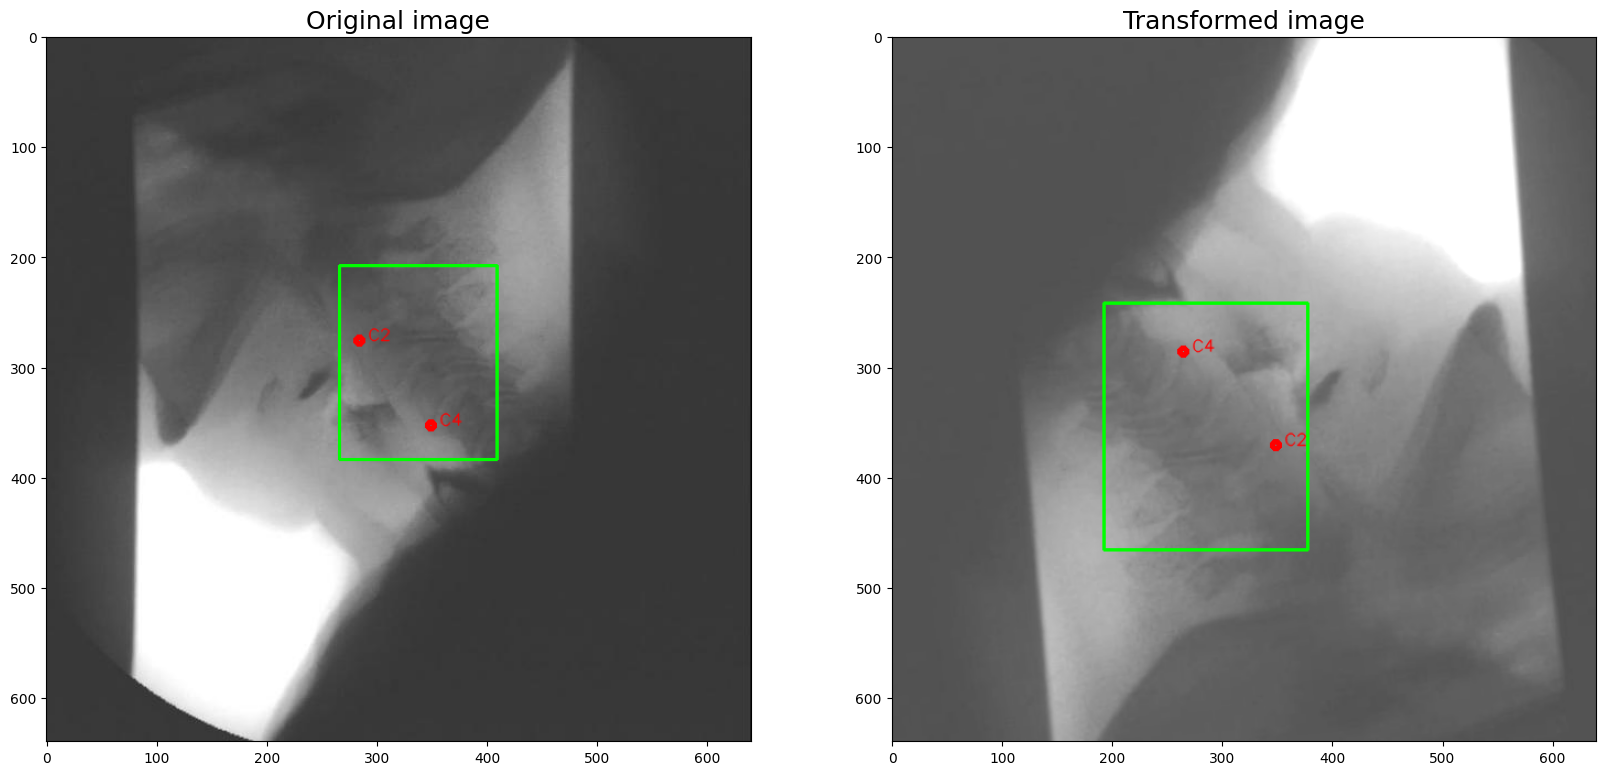

In [30]:
image = (batch[0][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes = batch[1][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

keypoints = []
for kps in batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    keypoints.append([kp[:2] for kp in kps])

image_original = (batch[2][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes_original = batch[3][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

keypoints_original = []
for kps in batch[3][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    keypoints_original.append([kp[:2] for kp in kps])

visualize(image, bboxes, keypoints, image_original, bboxes_original, keypoints_original)

## 5. Training

In [6]:
def get_model(num_keypoints, weights_path=None):

    anchor_generator = AnchorGenerator(sizes=(32, 64, 128, 256, 512), aspect_ratios=(0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0))
    model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=False,
                                                                   pretrained_backbone=True,
                                                                   num_keypoints=num_keypoints,
                                                                   num_classes = 2, # Background is the first class, object is the second class
                                                                   rpn_anchor_generator=anchor_generator)

    if weights_path:
        state_dict = torch.load(weights_path)
        model.load_state_dict(state_dict)

    return model

In [31]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

KEYPOINTS_FOLDER_TRAIN = '../dataset_rcnn_20251125_211948/fold1/treino'
KEYPOINTS_FOLDER_TEST = '../dataset_rcnn_20251125_211948/fold1/teste'

dataset_train = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=False)
dataset_test = ClassDataset(KEYPOINTS_FOLDER_TEST, transform=None, demo=False)

# Otimizado: batch_size=32 (testado, usa ~17.5GB), num_workers=8 para paralelizar I/O
data_loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True)
data_loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

model = get_model(num_keypoints = 2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)
num_epochs = 50

# Lists to store metrics for plotting
train_losses = []
val_bbox_ap = []
val_keypoint_ap = []

print(f"Treinando com: batch_size=32, lr=0.005, epochs={num_epochs}")
print(f"Device: {device}")
print(f"Dataset: {len(dataset_train)} train, {len(dataset_test)} test")
print("=" * 60)

for epoch in range(num_epochs):
    # Training
    metric_logger = train_one_epoch(model, optimizer, data_loader_train, device, epoch, print_freq=10)

    # Get average training loss
    train_loss = metric_logger.meters['loss'].global_avg
    train_losses.append(train_loss)

    lr_scheduler.step()

    # Evaluation
    coco_evaluator = evaluate(model, data_loader_test, device)

    # Get validation metrics (AP @ IoU=0.50:0.95)
    bbox_ap = coco_evaluator.coco_eval['bbox'].stats[0]  # AP for bbox
    keypoint_ap = coco_evaluator.coco_eval['keypoints'].stats[0]  # AP for keypoints

    val_bbox_ap.append(bbox_ap)
    val_keypoint_ap.append(keypoint_ap)

    print(f"\n{'='*60}")
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, BBox AP = {bbox_ap:.4f}, Keypoint AP = {keypoint_ap:.4f}")
    print(f"{'='*60}\n")

# Save model weights after training
torch.save(model.state_dict(), 'keypointsrcnn_weights.pth')
print("Model saved!")

Treinando com: batch_size=32, lr=0.005, epochs=50
Device: cuda
Dataset: 262 train, 63 test
Epoch: [0]  [0/9]  eta: 0:00:25  lr: 0.000629  loss: 9.4789 (9.4789)  loss_classifier: 0.7134 (0.7134)  loss_box_reg: 0.0132 (0.0132)  loss_keypoint: 8.0506 (8.0506)  loss_objectness: 0.6947 (0.6947)  loss_rpn_box_reg: 0.0070 (0.0070)  time: 2.8043  data: 1.2229  max mem: 20002
Epoch: [0]  [0/9]  eta: 0:00:25  lr: 0.000629  loss: 9.4789 (9.4789)  loss_classifier: 0.7134 (0.7134)  loss_box_reg: 0.0132 (0.0132)  loss_keypoint: 8.0506 (8.0506)  loss_objectness: 0.6947 (0.6947)  loss_rpn_box_reg: 0.0070 (0.0070)  time: 2.8043  data: 1.2229  max mem: 20002
Epoch: [0]  [8/9]  eta: 0:00:01  lr: 0.005000  loss: 9.0993 (9.0323)  loss_classifier: 0.3973 (0.3917)  loss_box_reg: 0.0157 (0.0169)  loss_keypoint: 7.9867 (7.9337)  loss_objectness: 0.6905 (0.6831)  loss_rpn_box_reg: 0.0070 (0.0069)  time: 1.5291  data: 0.1361  max mem: 20002
Epoch: [0] Total time: 0:00:13 (1.5389 s / it)
Epoch: [0]  [8/9]  eta: 0

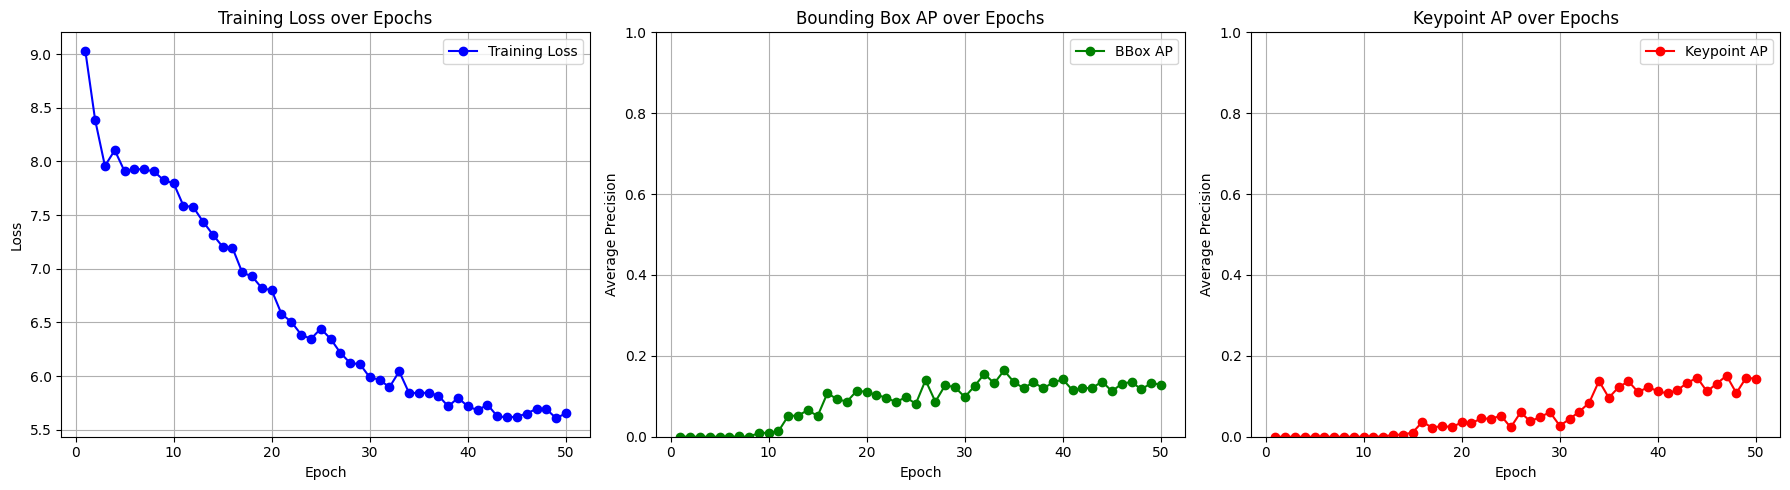


=== Training Summary ===
Final Training Loss: 5.6551
Final BBox AP: 0.1288
Final Keypoint AP: 0.1430
Best BBox AP: 0.1638 (Epoch 34)
Best Keypoint AP: 0.1511 (Epoch 47)


In [32]:
# Plot training metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(train_losses) + 1)

# Plot 1: Training Loss
axes[0].plot(epochs_range, train_losses, 'b-o', label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss over Epochs')
axes[0].legend()
axes[0].grid(True)

# Plot 2: BBox AP
axes[1].plot(epochs_range, val_bbox_ap, 'g-o', label='BBox AP')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average Precision')
axes[1].set_title('Bounding Box AP over Epochs')
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Plot 3: Keypoint AP
axes[2].plot(epochs_range, val_keypoint_ap, 'r-o', label='Keypoint AP')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Average Precision')
axes[2].set_title('Keypoint AP over Epochs')
axes[2].legend()
axes[2].grid(True)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== Training Summary ===")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final BBox AP: {val_bbox_ap[-1]:.4f}")
print(f"Final Keypoint AP: {val_keypoint_ap[-1]:.4f}")
print(f"Best BBox AP: {max(val_bbox_ap):.4f} (Epoch {val_bbox_ap.index(max(val_bbox_ap)) + 1})")
print(f"Best Keypoint AP: {max(val_keypoint_ap):.4f} (Epoch {val_keypoint_ap.index(max(val_keypoint_ap)) + 1})")

## 6. Visualizing model predictions

In [33]:
iterator = iter(data_loader_test)

In [34]:
images, targets = next(iterator)
images = list(image.to(device) for image in images)

with torch.no_grad():
    model.to(device)
    model.eval()
    output = model(images)

print("Predictions: \n", output)

Predictions: 
 [{'boxes': tensor([[1.6784e+02, 1.3558e+02, 2.5887e+02, 2.9404e+02],
        [1.3910e+02, 1.0045e+02, 2.3382e+02, 2.5669e+02],
        [1.7602e+02, 2.0525e+02, 2.8372e+02, 2.8744e+02],
        [1.5379e+02, 1.7989e+02, 2.6436e+02, 2.6050e+02],
        [1.4338e+02, 1.5600e+02, 2.5670e+02, 2.3934e+02],
        [1.2339e+02, 1.0406e+02, 2.9042e+02, 2.8923e+02],
        [1.3240e+02, 1.9379e+02, 3.2520e+02, 2.8727e+02],
        [1.4960e+02, 2.1060e+02, 3.2189e+02, 2.6168e+02],
        [1.5989e+02, 2.2517e+02, 3.3900e+02, 2.7968e+02],
        [1.9227e+02, 2.2457e+02, 3.1229e+02, 3.0713e+02],
        [2.0072e+02, 1.8637e+02, 2.8529e+02, 3.3225e+02],
        [1.4546e+02, 1.6908e+01, 2.5945e+02, 3.1961e+02],
        [1.1715e+02, 1.7042e+02, 2.8660e+02, 2.2094e+02],
        [1.2760e+02, 6.1843e+01, 2.1179e+02, 2.1641e+02],
        [1.7352e+02, 1.4192e+02, 2.9425e+02, 3.5184e+02],
        [9.4060e+01, 1.3621e+02, 2.9749e+02, 2.2975e+02],
        [8.7052e+01, 3.9866e+01, 2.4905e+02, 2

Scores: [0.6622719  0.62752545 0.6261688  0.6260839  0.47549057 0.43126887
 0.33750618 0.26510108 0.253532   0.22488931]...
Max score: 0.6622719168663025
Predicted bboxes: [[167, 135, 258, 294]]
Predicted keypoints: [[[177, 194], [218, 268]]]
Ground truth bboxes: [[166, 137, 270, 301]]
Ground truth keypoints: [[[179, 195], [222, 271]]]


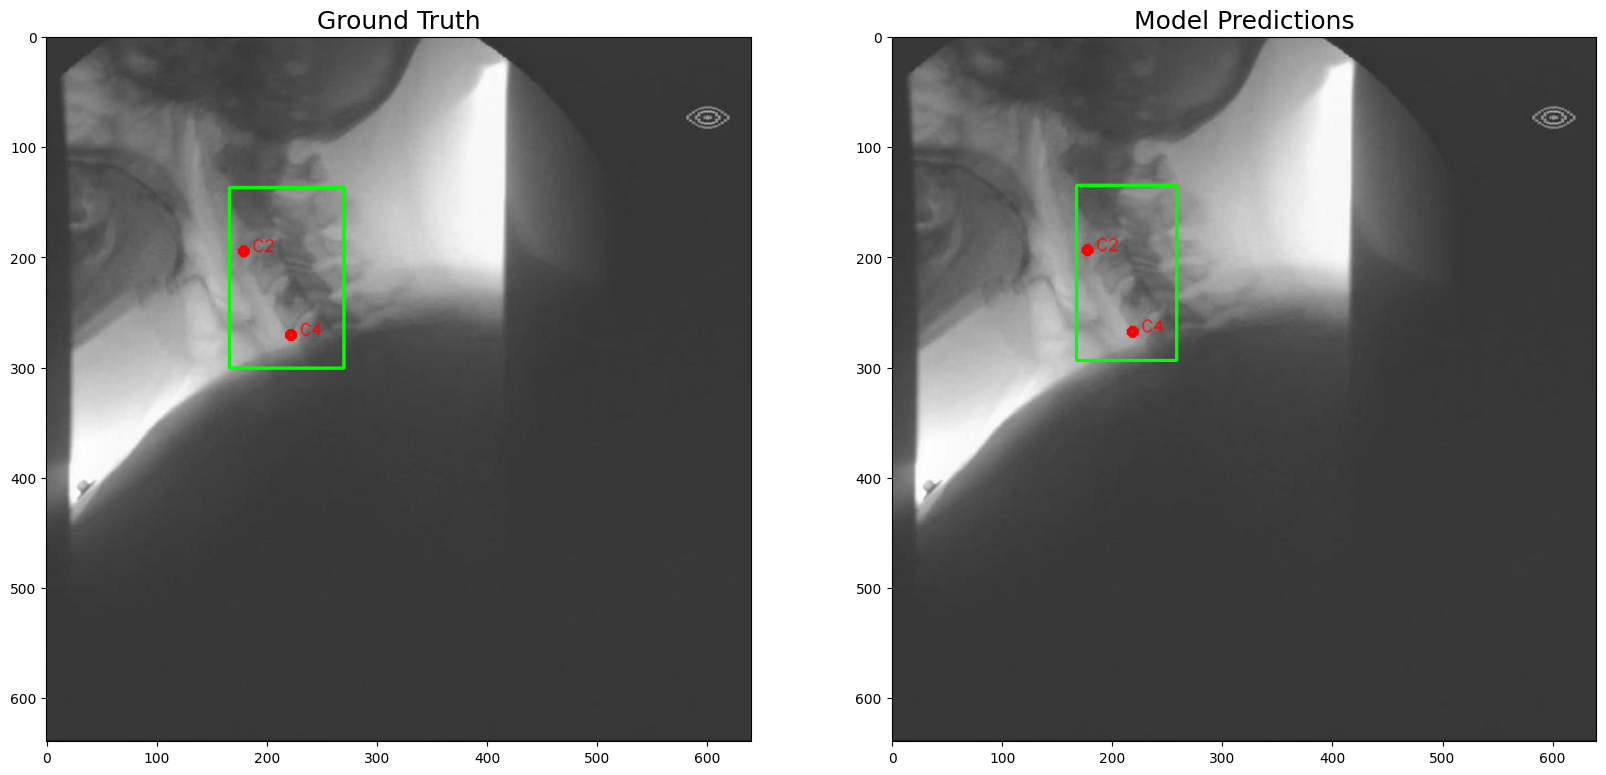

In [35]:
# Prepare predicted image
image = (images[0].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)
scores = output[0]['scores'].detach().cpu().numpy()

print(f"Scores: {scores[:10]}...")  # Show first 10 scores
print(f"Max score: {scores.max() if len(scores) > 0 else 'No detections'}")

high_scores_idxs = np.where(scores > 0.5)[0].tolist()
post_nms_idxs = torchvision.ops.nms(output[0]['boxes'][high_scores_idxs], output[0]['scores'][high_scores_idxs], 0.3).cpu().numpy() if len(high_scores_idxs) > 0 else []

keypoints_pred = []
for kps in output[0]['keypoints'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
    keypoints_pred.append([list(map(int, kp[:2])) for kp in kps])

bboxes_pred = []
for bbox in output[0]['boxes'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
    bboxes_pred.append(list(map(int, bbox.tolist())))

print(f"Predicted bboxes: {bboxes_pred}")
print(f"Predicted keypoints: {keypoints_pred}")

# Prepare ground truth
target = targets[0]
bboxes_gt = target['boxes'].detach().cpu().numpy().astype(np.int32).tolist()
keypoints_gt = []
for kps in target['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    keypoints_gt.append([kp[:2] for kp in kps])

print(f"Ground truth bboxes: {bboxes_gt}")
print(f"Ground truth keypoints: {keypoints_gt}")

# Visualize: Ground Truth vs Predictions
image_pred = image.copy()
image_gt = image.copy()

# Draw predictions
for bbox in bboxes_pred:
    cv2.rectangle(image_pred, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
for kps in keypoints_pred:
    for idx, kp in enumerate(kps):
        cv2.circle(image_pred, tuple(kp), 3, (255,0,0), 3)
        cv2.putText(image_pred, " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1, cv2.LINE_AA)

# Draw ground truth
for bbox in bboxes_gt:
    cv2.rectangle(image_gt, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
for kps in keypoints_gt:
    for idx, kp in enumerate(kps):
        cv2.circle(image_gt, tuple(kp), 3, (255,0,0), 3)
        cv2.putText(image_gt, " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1, cv2.LINE_AA)

f, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(image_gt)
ax[0].set_title('Ground Truth', fontsize=18)
ax[1].imshow(image_pred)
ax[1].set_title('Model Predictions', fontsize=18)
plt.show()